# UD Dep Extract - Demo Notebook

**Extracted dependency structures from Universal Dependencies treebanks.**

This notebook demonstrates the dependency structure extraction pipeline from UD v2.17 treebanks
(via `commul/universal_dependencies` on HuggingFace). For each sentence with >=15 tokens, the pipeline:

1. Parses `head` fields to integer arrays
2. Extracts `deprel` (dependency relation) arrays
3. Computes **dependency distance sequences** (DD_i = |position_i - head_i|) for non-root tokens
4. Computes treebank-level metadata: Case morphological feature proportions, spoken/written modality, genre, sentence counts

The demo uses a mini subset (3 treebanks, 9 sentences) to illustrate the processing logic and visualize dependency distance distributions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — all imports are stdlib + core scientific

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import re
import numpy as np
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-c3cfa4-sequential-dependency-distance-anti-corr/main/dataset_iter1_ud_dep_extract/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'])} treebanks")
print(f"Metadata keys: {list(data['metadata'].keys())}")
print(f"Treebank summaries: {len(data['metadata']['treebank_summaries'])} entries")

Loaded data with 3 treebanks
Metadata keys: ['source', 'ud_version', 'extraction_date', 'min_token_threshold', 'primary_threshold', 'total_treebanks_processed', 'qualifying_treebanks_ge50_at_20tok', 'total_qualifying_sentences', 'spoken_treebanks', 'treebank_summaries']
Treebank summaries: 6 entries


## Configuration

Define the tunable parameters used in the extraction pipeline. These match the original script's constants.

In [5]:
# --- Configuration ---
# Minimum token count for a sentence to be included
MIN_TOKENS = 15
# Primary threshold for qualification counting
PRIMARY_THRESHOLD = 20
# Minimum sentences at primary threshold for a treebank to qualify
QUALIFICATION_MIN = 50
# Compact JSON separators
COMPACT = (",", ":")
# Known spoken treebanks
SPOKEN_TREEBANKS = {
    "fr_rhapsodie", "fr_parisstories", "en_childes", "en_eslspok",
    "sl_sst", "no_nynorsklia", "bej_nsc", "pcm_nsc", "kpv_lattice",
    "el_cretan", "nhi_itml", "qfn_fame", "qtd_sagt", "swl_sslc", "es_coser",
}
# Max datasets to process (None = all in mini data)
MAX_DATASETS = None

## Sentence Processing

The core function: given a sentence's `head_array` and `deprel_array`, validate the heads, then compute the **dependency distance sequence** where DD_i = |position_i - head_i| for each non-root token.

In [6]:
def process_sentence(input_data: dict, config_name: str) -> tuple:
    """Process one pre-extracted UD sentence example.

    Takes the parsed input dict (head_array, deprel_array) and validates it,
    then recomputes the dependency distance sequence.

    Returns:
        (result_dict or None, stats_dict)
    """
    head_array = input_data["head_array"]
    deprel_array = input_data["deprel_array"]
    token_count = len(head_array)

    stats = {
        "total": 1,
        "token_count_sum": token_count,
        "multi_root": 0,
        "skipped_validation": 0,
    }

    # Skip short sentences
    if token_count < MIN_TOKENS:
        return None, stats

    if len(deprel_array) != token_count:
        stats["skipped_validation"] = 1
        return None, stats

    # Validate head values
    root_count = 0
    valid = True
    for h in head_array:
        if h < 0 or h > token_count:
            valid = False
            break
        if h == 0:
            root_count += 1

    if not valid or root_count == 0:
        stats["skipped_validation"] = 1
        return None, stats

    if root_count > 1:
        stats["multi_root"] = 1

    # Compute dependency distance sequence (non-root tokens, linear order)
    dd_sequence = []
    for i in range(token_count):
        h = head_array[i]
        if h == 0:
            continue  # Skip root token
        position = i + 1  # Convert to 1-indexed
        dd = abs(position - h)
        dd_sequence.append(dd)

    # Length bucket
    length_bucket = "ge20" if token_count >= PRIMARY_THRESHOLD else "ge15"

    result = {
        "dd_sequence": dd_sequence,
        "token_count": token_count,
        "length_bucket": length_bucket,
        "config_name": config_name,
    }
    return result, stats

## Process All Treebanks

Iterate over each treebank dataset in the loaded data, parse the JSON-encoded input/output strings, and recompute dependency distances. Collect per-treebank statistics and all processed results.

In [7]:
datasets_list = data["datasets"]
if MAX_DATASETS is not None:
    datasets_list = datasets_list[:MAX_DATASETS]

all_results = []          # per-sentence processed results
treebank_stats = {}       # per-treebank aggregated stats
all_dd_by_treebank = {}   # dd_sequences grouped by treebank

for ds_entry in datasets_list:
    config_name = ds_entry["dataset"]
    examples = ds_entry["examples"]

    tb_total = 0
    tb_processed = 0
    tb_ge15 = 0
    tb_ge20 = 0
    tb_dd_all = []

    for ex in examples:
        input_data = json.loads(ex["input"])
        output_data = json.loads(ex["output"])

        result, stats = process_sentence(input_data, config_name)
        tb_total += stats["total"]

        if result is not None:
            tb_processed += 1
            tb_ge15 += 1
            if result["token_count"] >= PRIMARY_THRESHOLD:
                tb_ge20 += 1
            tb_dd_all.extend(result["dd_sequence"])

            # Verify our recomputed dd_sequence matches the stored one
            assert result["dd_sequence"] == output_data["dd_sequence"], \
                f"Mismatch for {config_name}/{ex['metadata_sentence_id']}"

            all_results.append(result)

    all_dd_by_treebank[config_name] = tb_dd_all

    treebank_stats[config_name] = {
        "total_examples": tb_total,
        "processed": tb_processed,
        "ge15": tb_ge15,
        "ge20": tb_ge20,
        "mean_dd": np.mean(tb_dd_all) if tb_dd_all else 0.0,
    }

    print(f"Treebank {config_name}: {tb_processed}/{tb_total} sentences processed, "
          f"ge20={tb_ge20}, mean_dd={treebank_stats[config_name]['mean_dd']:.2f}")

print(f"\nTotal processed sentences: {len(all_results)}")
print("All recomputed dd_sequences match stored values.")

Treebank af_afribooms: 3/3 sentences processed, ge20=3, mean_dd=3.17
Treebank akk_riao: 3/3 sentences processed, ge20=2, mean_dd=5.07
Treebank sq_staf: 3/3 sentences processed, ge20=1, mean_dd=2.79

Total processed sentences: 9
All recomputed dd_sequences match stored values.


## Treebank Metadata Summary

Display the stored treebank-level metadata including Case feature proportions, spoken/written modality, qualification status, and sentence counts.

In [8]:
# Print treebank summaries from metadata
summaries = data["metadata"]["treebank_summaries"]

print(f"{'Treebank':<20} {'Lang':<6} {'Total':>7} {'>=15':>6} {'>=20':>6} {'Case%':>7} {'Spoken':<7} {'Qualifies':<9}")
print("-" * 80)
for tb_id, s in summaries.items():
    print(f"{s['treebank_id']:<20} {s['language']:<6} {s['total_sentences']:>7} "
          f"{s['sentences_ge15']:>6} {s['sentences_ge20']:>6} "
          f"{s['case_feature_proportion']:>7.4f} {str(s['is_spoken']):<7} {str(s['qualifies_primary']):<9}")

print(f"\nFull extraction stats:")
print(f"  Total treebanks processed: {data['metadata']['total_treebanks_processed']}")
print(f"  Qualifying treebanks (>=50 at 20-tok): {data['metadata']['qualifying_treebanks_ge50_at_20tok']}")
print(f"  Total qualifying sentences: {data['metadata']['total_qualifying_sentences']:,}")
print(f"  Spoken treebanks: {data['metadata']['spoken_treebanks']}")

Treebank             Lang     Total   >=15   >=20   Case% Spoken  Qualifies
--------------------------------------------------------------------------------
af_afribooms         af        1934   1526   1181  0.0943 False   True     
akk_riao             akk       1874    456    267  0.1988 False   True     
sq_staf              sq         200     97     63  0.3607 False   True     
abq_atb              abq         98      4      0  0.0015 False   False    
ab_abnc              ab        1316    118     23  0.0156 False   False    
akk_pisandub         akk        101     49     34  0.0000 False   False    

Full extraction stats:
  Total treebanks processed: 336
  Qualifying treebanks (>=50 at 20-tok): 233
  Total qualifying sentences: 976,187
  Spoken treebanks: 16


## Visualization

**Top**: Dependency distance distributions per treebank (histogram). Most dependency distances are short (1-3), reflecting the well-known tendency for syntactically related words to appear close together.

**Bottom**: Per-sentence mean dependency distance vs. sentence length (token count), showing how average DD varies with sentence size.

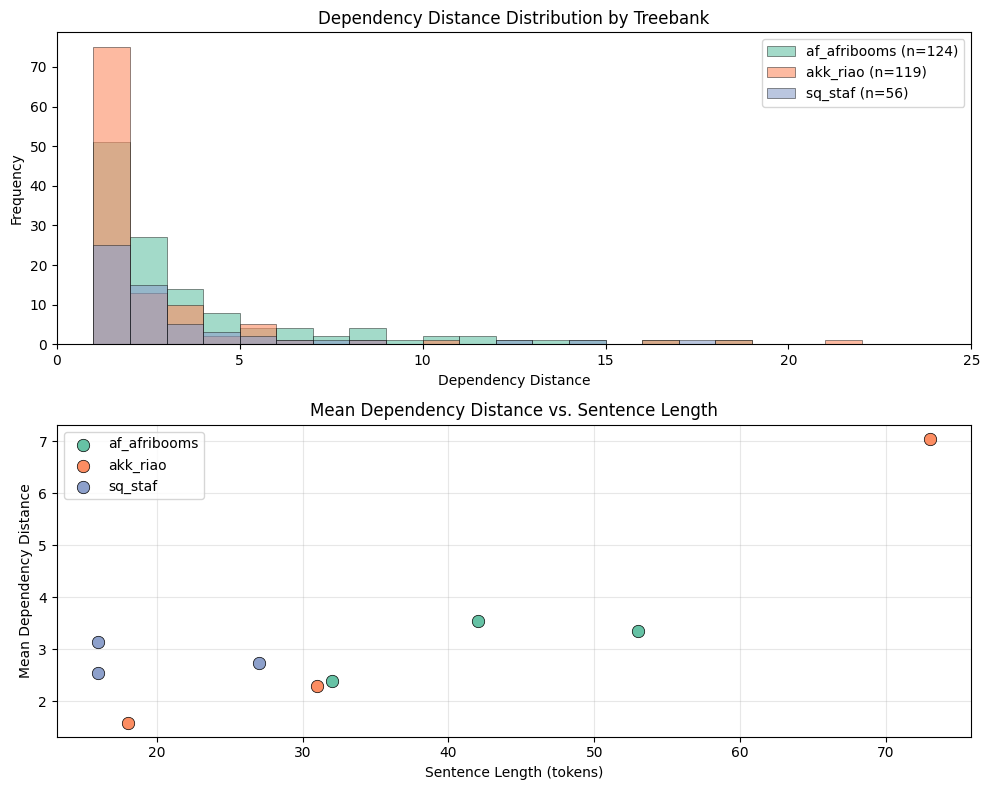

Saved visualization to dd_visualization.png


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# --- Plot 1: DD distribution per treebank ---
ax1 = axes[0]
colors = plt.cm.Set2.colors
for idx, (tb_name, dd_vals) in enumerate(all_dd_by_treebank.items()):
    if dd_vals:
        ax1.hist(dd_vals, bins=range(1, max(dd_vals) + 2), alpha=0.6,
                 label=f"{tb_name} (n={len(dd_vals)})", color=colors[idx % len(colors)],
                 edgecolor="black", linewidth=0.5)
ax1.set_xlabel("Dependency Distance")
ax1.set_ylabel("Frequency")
ax1.set_title("Dependency Distance Distribution by Treebank")
ax1.legend()
ax1.set_xlim(0, 25)

# --- Plot 2: Mean DD vs sentence length ---
ax2 = axes[1]
for idx, (tb_name, _) in enumerate(all_dd_by_treebank.items()):
    tb_results = [r for r in all_results if r["config_name"] == tb_name]
    if tb_results:
        lengths = [r["token_count"] for r in tb_results]
        mean_dds = [np.mean(r["dd_sequence"]) for r in tb_results]
        ax2.scatter(lengths, mean_dds, label=tb_name, color=colors[idx % len(colors)],
                    s=80, edgecolors="black", linewidth=0.5, zorder=3)
ax2.set_xlabel("Sentence Length (tokens)")
ax2.set_ylabel("Mean Dependency Distance")
ax2.set_title("Mean Dependency Distance vs. Sentence Length")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dd_visualization.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved visualization to dd_visualization.png")